### Setting up a new kpms project

In [ ]:
import keypoint_moseq as kpms
import os

data_dir = '/Users/annateruel/Desktop/interpolated' #where your dlc data is stored
project_dir = '/Users/annateruel/Desktop/kpms-3cham-wanhui' #project directory
config = lambda: kpms.load_config(project_dir)
dlc_config = os.path.join(data_dir, 'config.yaml')
kpms.setup_project(project_dir, deeplabcut_config=dlc_config, overwrite=True) #setting up dlc_config file

This line of code should create a project config file. 

### Loading data

In [ ]:
import keypoint_moseq as kpms
import os
project_dir = '/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26'  
config = lambda: kpms.load_config(project_dir)

kp_data_path = '/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/dlc' 
coordinates, confidences, bodyparts = kpms.load_keypoints(kp_data_path, 'deeplabcut')

data, metadata = kpms.format_data(coordinates, confidences, **config())

### Callibration

In [ ]:
%matplotlib widget
kpms.noise_calibration(project_dir, coordinates, confidences, **config())

### Visualization

#### Trajectory plots

In [ ]:
model_name = '2026_01_09-12_30_09'
results = kpms.load_results(project_dir, model_name)
kpms.generate_trajectory_plots(coordinates, 
                               results, 
                               project_dir, 
                               model_name, 
                               **config())

#### Grid movies

Important here: what "density" sampling is doing conceptually? 

When you use ``sampling_opyions['mode'] == 'density'`` Keypoint-MoSeq is not randomly selecting syllable instances. You see the most typical realizations of a syllable, not the rare or weird ones.

When you're using smaller neighbors, you might see fine-grained variations. But, when you use larger neighbors, the density is smoothed over larger neighborhoods, suppressing rare variants. 

In [ ]:
model_name = '2026_01_09-12_30_09'
results = kpms.load_results(project_dir, model_name)
kpms.generate_grid_movies(results= results, 
                          project_dir = project_dir, 
                          model_name = model_name, 
                          coordinates=coordinates, 
                          dot_color=(0, 0, 255),
                          dot_radius=4,
                          rows = 2, 
                          cols = 5, 
                          overlay_keypoints= True,
                          sampling_options={'mode':'density', 'n_neighbors':100},
                          **config());

#### Dendogram

In [ ]:
model_name = '2026_01_09-12_30_09'
results = kpms.load_results(project_dir, model_name)
kpms.plot_similarity_dendrogram(coordinates, 
                                results, 
                                project_dir, 
                                model_name, 
                                figsize=(10, 10),
                                **config())

### Asign groups 

In [ ]:
model_name = '2026_01_09-12_30_09'
results = kpms.load_results(project_dir, model_name)

In [ ]:
from keypoint_moseq.analysis import interactive_group_setting
interactive_group_setting(project_dir, model_name)

In [ ]:
from keypoint_moseq.analysis_v2 import interactive_group_setting
interactive_group_setting(project_dir, model_name, num_factors = 1)

### Running statistics

New code for multiple factors:

In [ ]:
from keypoint_moseq.analysis_v2 import compute_moseq_df, compute_stats_df
moseq_df = compute_moseq_df(project_dir = project_dir, 
                            model_name= model_name, 
                            smooth_heading=True, 
                            num_factors=1)

moseq_df.to_csv(os.path.join(project_dir, model_name, '/Users/annateruel/Desktop/moseq_df.csv'), index=False)

In [ ]:
stats_df = compute_stats_df(
    project_dir,
    model_name,
    moseq_df,
    min_frequency=0.01,
    fps=30,
    num_factors=1,
)
stats_df.to_csv(os.path.join(project_dir, model_name, '/Users/annateruel/Desktop/stats_df.csv'), index=False)

Old code for a single factor: 

In [ ]:
from keypoint_moseq.analysis import compute_moseq_df, compute_stats_df
moseq_df = compute_moseq_df(project_dir = project_dir, 
                            model_name= model_name, 
                            smooth_heading=True)

In [ ]:
moseq_df.to_csv(os.path.join(project_dir, model_name, '/Users/annateruel/Desktop/moseq_df.csv'), index=False)

In [ ]:
stats_df = compute_stats_df(
    project_dir,
    model_name,
    moseq_df,
    min_frequency=0.01,
    fps=30,
)

In [ ]:
stats_df.to_csv(os.path.join(project_dir, model_name, '/Users/annateruel/Desktop/stats_df.csv'), index=False)

In [ ]:
from keypoint_moseq.analysis import run_kruskal
import os

stats_df_out, perm_null, sig_mask = run_kruskal(
    stats_df,
    statistic="frequency",
    n_perm=10000,
    seed=42,
    thresh=0.05,
    mc_method="fdr_bh"
)
outdir = "/Users/annateruel/Desktop/kruskal_output"
os.makedirs(outdir, exist_ok=True)
stats_df_out = stats_df_out.reset_index().rename(columns={'index': 'syllable'})
stats_df_out.to_csv("kruskal_results.csv", index=False)
perm_null.to_csv(os.path.join(outdir, "kruskal_perm_null.csv"), index=False)
# sig_mask.to_csv(os.path.join(outdir, "kruskal_significant_mask.csv"), index=False)

In [ ]:
from keypoint_moseq.analysis import plot_syll_stats_with_sem

plot_syll_stats_with_sem(stats_df,
                         project_dir, 
                         model_name, 
                         plot_sig = True)


In [ ]:
from keypoint_moseq.analysis_v2 import plot_syll_stats_with_sem_grouped

plot_syll_stats_with_sem_grouped(
    stats_df,
    project_dir,
    model_name,
    save_dir=None,
    plot_sig=True,
    thresh=0.05,
    stat="frequency",
    order="stat",
    num_factors=1,
    group_to_plot="group",
    groups=None,
    ctrl_group=None,
    exp_group=None,
    colors=None,
    join=False,
    figsize=(8, 4),
)

### Label syllables

In [ ]:
kpms.label_syllables(project_dir, model_name, moseq_df)

### Transition matrix

In [1]:
import keypoint_moseq as kpms
import os
project_dir = '/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26'  
config = lambda: kpms.load_config(project_dir)

kp_data_path = '/Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/dlc' 
coordinates, confidences, bodyparts = kpms.load_keypoints(kp_data_path, 'deeplabcut')

data, metadata = kpms.format_data(coordinates, confidences, **config())

model_name = '2026_01_09-12_30_09'
results = kpms.load_results(project_dir, model_name)


Loading keypoints: 100%|██████████████| 148/148 [00:15<00:00,  9.67it/s]


Group(s): group1, group2, group3, group4
Saved figure to /Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/2026_01_09-12_30_09/figures/transition_matrices.png


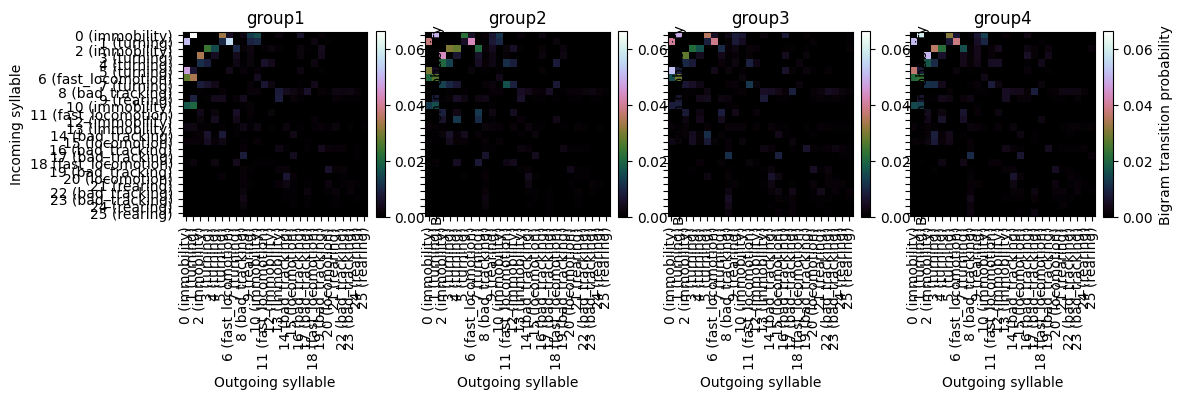

In [2]:
normalize = "bigram"  # normalization method ("bigram", "rows" or "columns")

trans_mats, usages, groups, syll_include = kpms.generate_transition_matrices(
    project_dir,
    model_name,
    normalize=normalize,
    min_frequency=0.005,  # minimum syllable frequency to include
)

kpms.visualize_transition_bigram(
    project_dir,
    model_name,
    groups,
    trans_mats,
    syll_include,
    normalize=normalize,
    show_syllable_names=True,  # label syllables by index (False) or index and name (True)
)

Saved figure to /Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/2026_01_09-12_30_09/figures/transition_graphs_diff.png


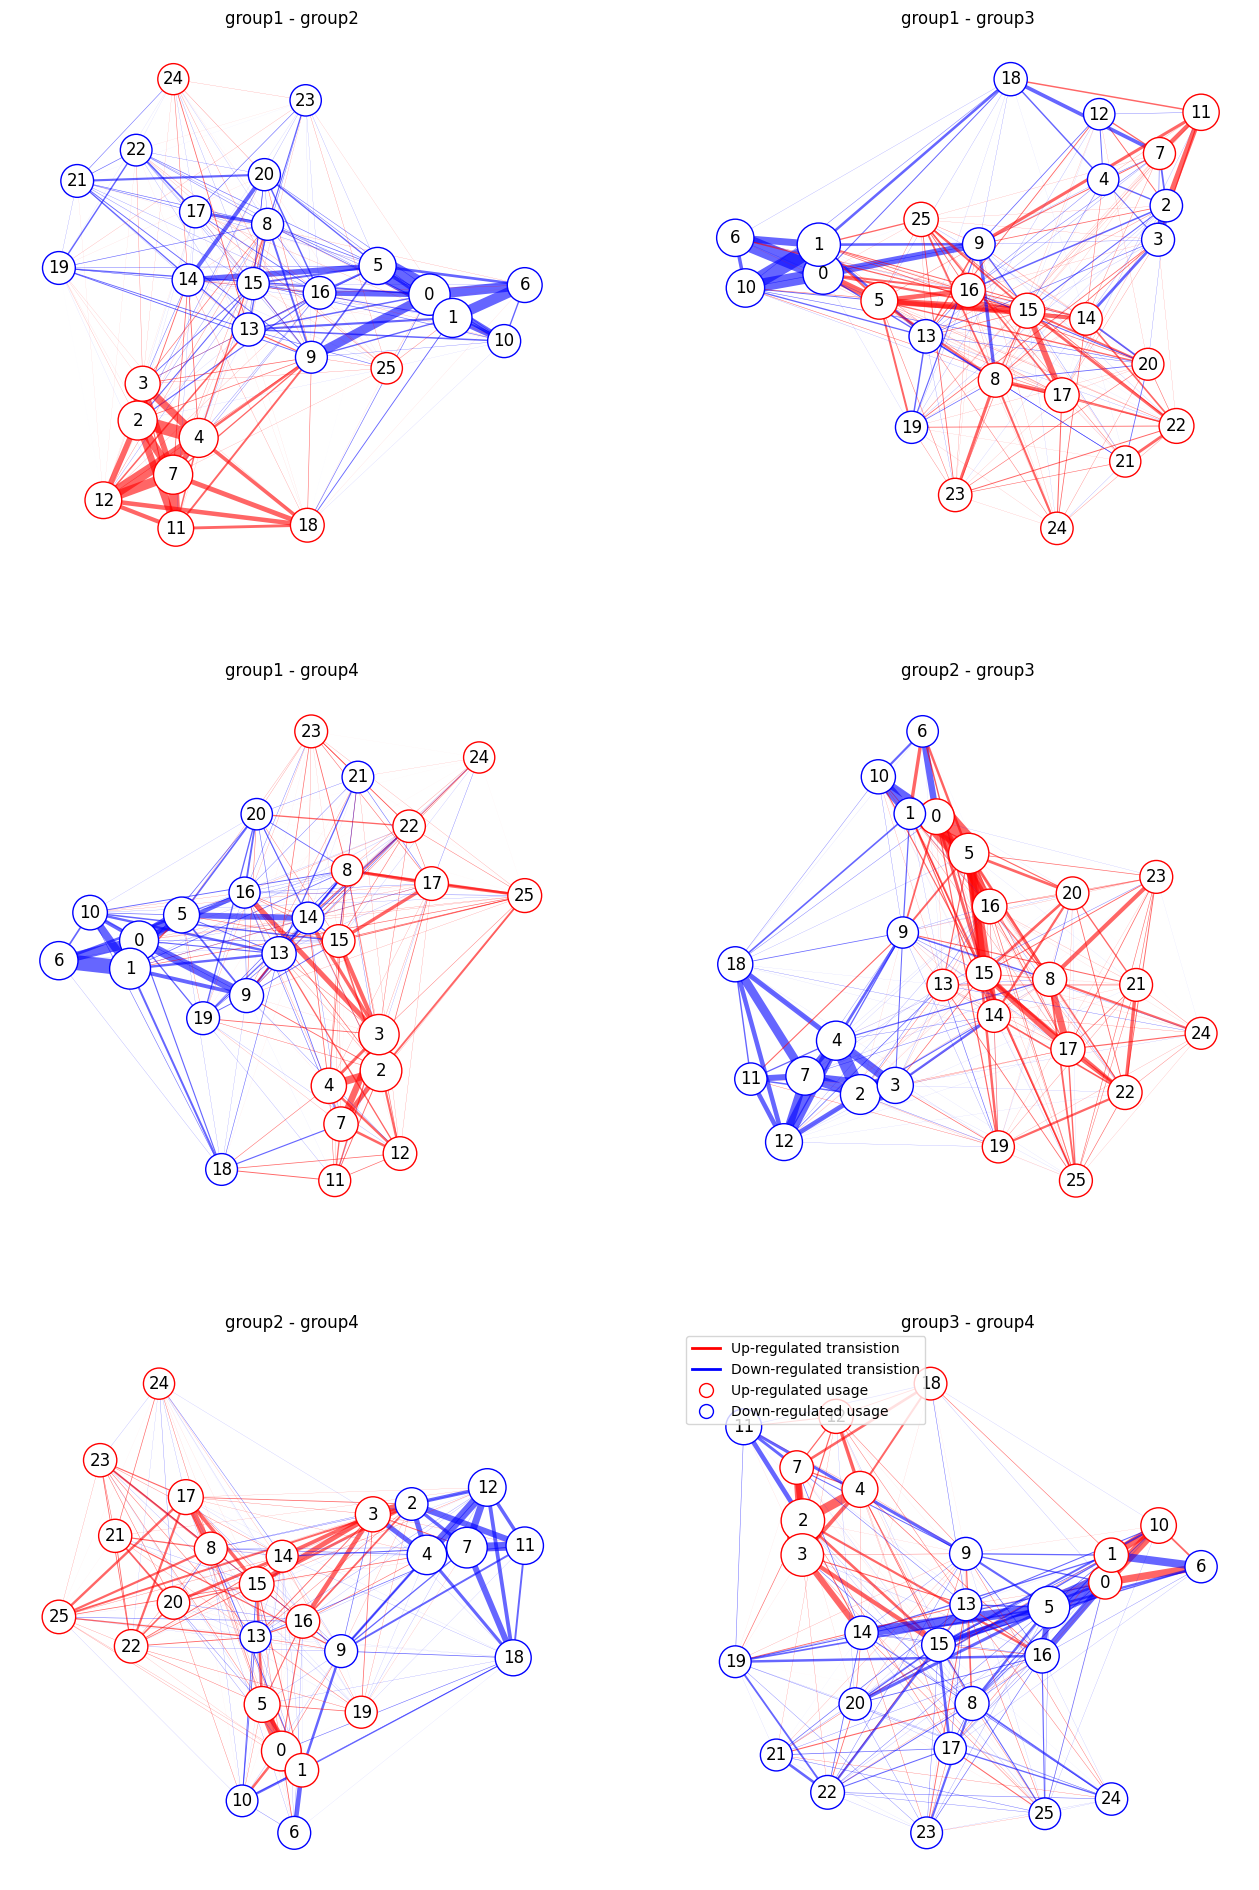

In [3]:
kpms.plot_transition_graph_difference(
    project_dir, model_name, groups, trans_mats, usages, syll_include, layout="spring"
)

Saved figure to /Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/2026_01_09-12_30_09/figures/transition_graphs.png


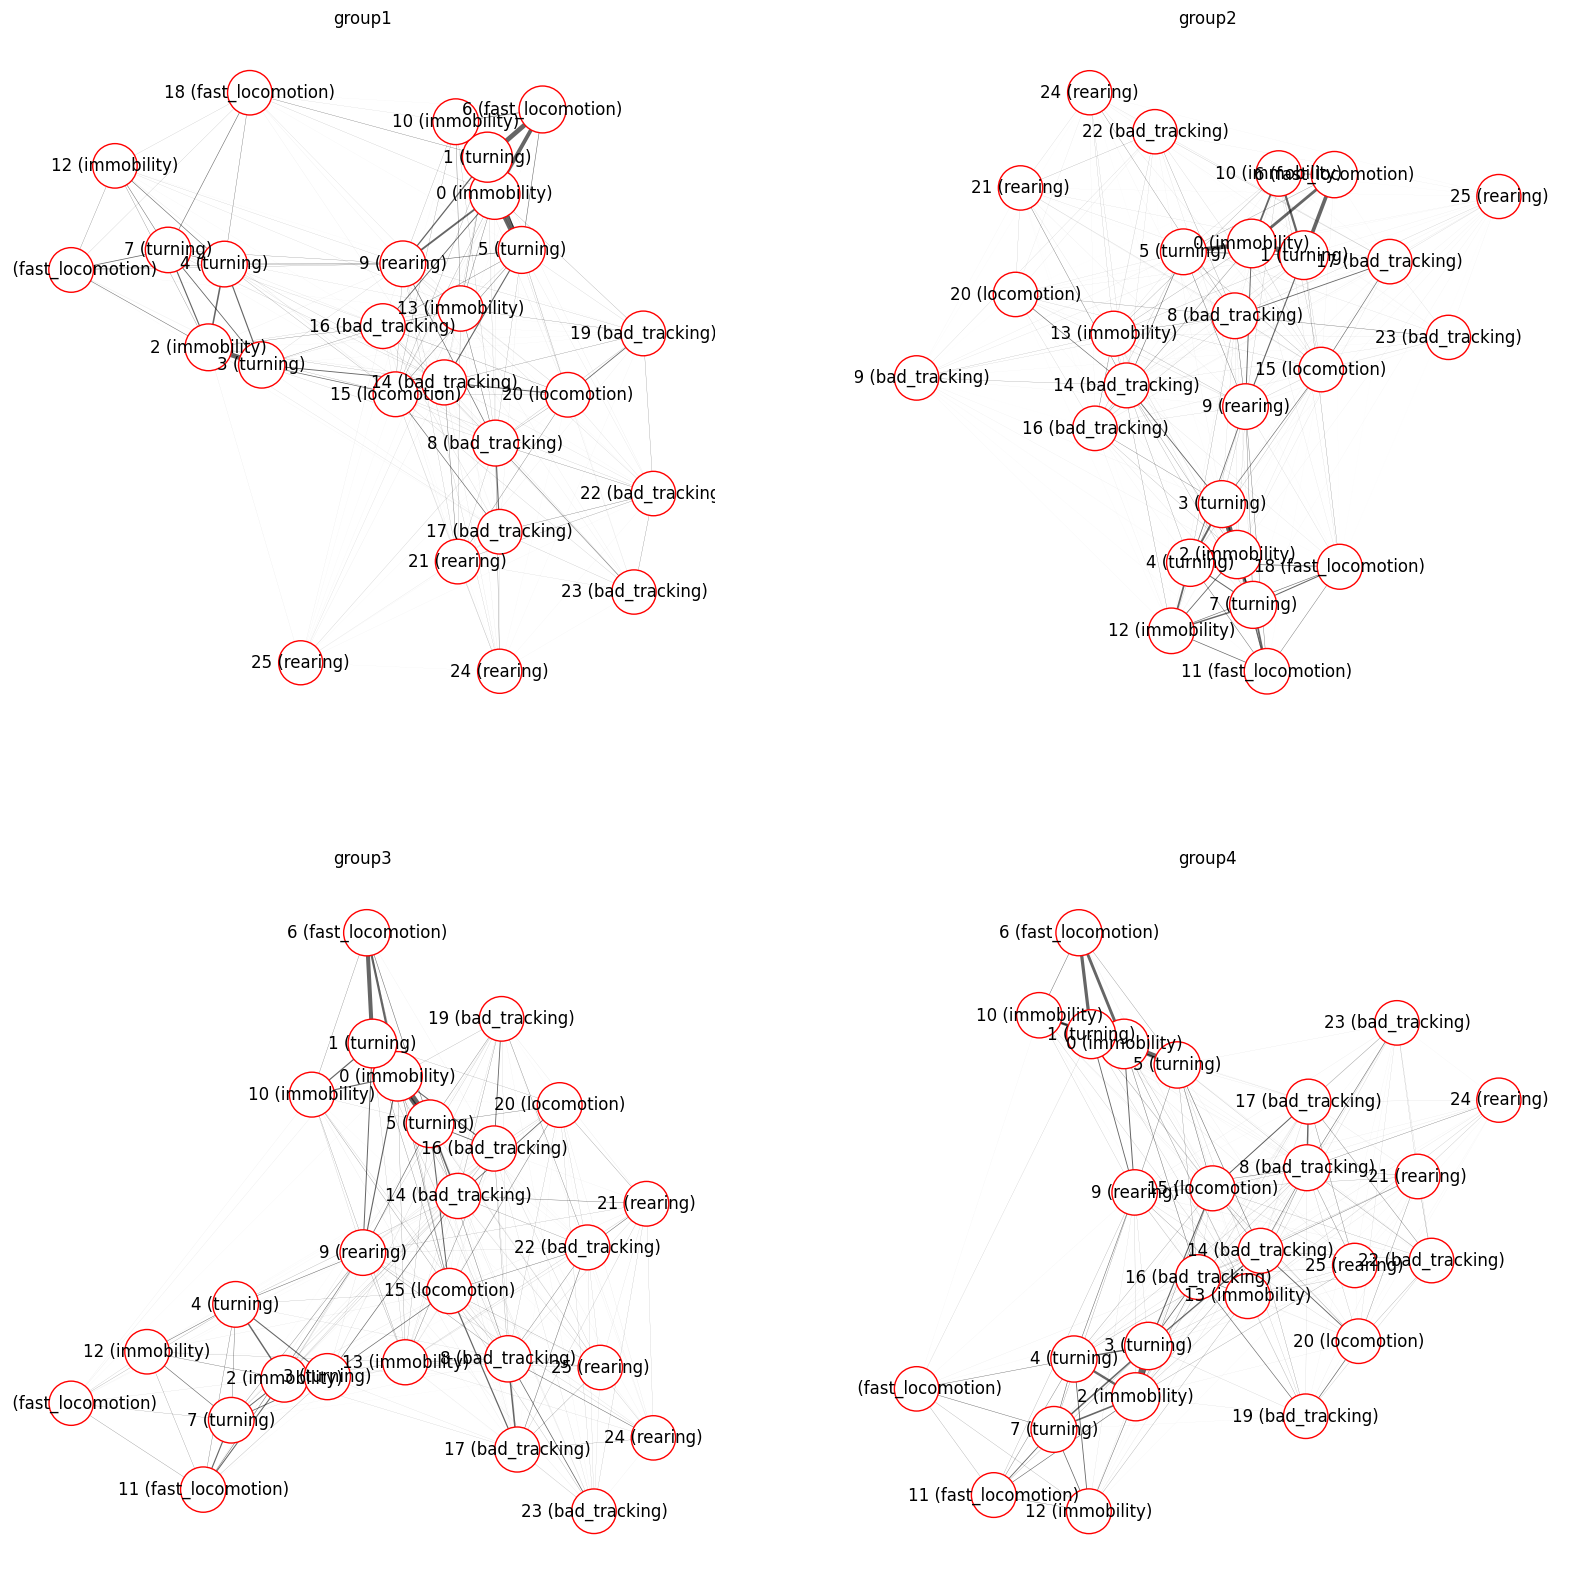

In [4]:
kpms.plot_transition_graph_group(
    project_dir,
    model_name,
    groups,
    trans_mats,
    usages,
    syll_include,
    layout="spring",  # transition graph layout ("circular" or "spring")
    show_syllable_names=True,  # label syllables by index (False) or index and name (True)
)

grouping syllables to make the matrix more simple

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keypoint_moseq.analysis_v2 import normalize_transition_matrix

def save_analysis_figure_v2(fig, plot_name, project_dir, model_name, save_dir=None,
                           formats=("svg","pdf"), dpi=300):
    if save_dir is None:
        save_dir = os.path.join(project_dir, model_name, "figures")
    os.makedirs(save_dir, exist_ok=True)
    base = os.path.join(save_dir, plot_name)

    if isinstance(formats, str):
        formats = (formats,)

    for fmt in formats:
        fig.savefig(f"{base}.{fmt}", dpi=dpi, bbox_inches="tight")
    print(f"Saved: {base}.{'/'.join(formats)}")
def group_transitions_posthoc(
    project_dir,
    model_name,
    trans_mats,
    usages,
    syll_include,
    group_col="label",
    fillna="UNLABELED",
    normalize="bigram",
):
    """
    Returns:
      grouped_trans_mats: list of (K,K) grouped matrices (same length as trans_mats)
      grouped_usages:     list of (K,) grouped usages
      group_names:        list of str length K in group-id order
      grp_ids:            array length S, group id per syllable index in syll_include
    """
    syll_info_path = os.path.join(project_dir, model_name, "syll_info.csv")
    info = pd.read_csv(syll_info_path)
    info["syllable"] = info["syllable"].astype(int)

    if group_col not in info.columns:
        raise KeyError(f"{group_col=} not found in syll_info.csv. Columns: {list(info.columns)}")

    info[group_col] = info[group_col].fillna(fillna)
    syll_to_name = dict(zip(info["syllable"], info[group_col]))

    syll_include = np.asarray(syll_include).astype(int)
    included_names = [syll_to_name.get(int(s), fillna) for s in syll_include]

    group_names = sorted(set(included_names))
    name_to_gid = {n:i for i, n in enumerate(group_names)}
    grp_ids = np.array([name_to_gid[n] for n in included_names], dtype=int)
    K = len(group_names)

    # one-hot assignment (S,K)
    A = np.eye(K, dtype=float)[grp_ids]

    grouped_trans_mats = []
    grouped_usages = []

    for T, u in zip(trans_mats, usages):
        T = np.asarray(T)
        u = np.asarray(u)

        # block-sum: (K,K)
        G = A.T @ T @ A
        G = normalize_transition_matrix(G, normalize)

        # usage: (K,)
        U = A.T @ u

        grouped_trans_mats.append(G)
        grouped_usages.append(U)

    return grouped_trans_mats, grouped_usages, group_names, grp_ids
def visualize_grouped_transition_bigram(
    project_dir,
    model_name,
    group,
    grouped_trans_mats,
    group_names,
    save_dir=None,
    normalize="bigram",
    figsize=(12, 6),
    cmap = 'Magma',
    formats = 'svg',
):
    """
    Same as visualize_transition_bigram, but axes are behavior-group names.
    """
    K = grouped_trans_mats[0].shape[0]
    assert K == len(group_names)

    fig, ax = plt.subplots(1, len(group), figsize=figsize, sharex=False, sharey=True)
    title_map = dict(bigram="Bigram", columns="Incoming", rows="Outgoing")
    color_lim = max([x.max() for x in grouped_trans_mats])

    axs = [ax] if len(group) == 1 else ax.flat

    for i, g in enumerate(group):
        h = axs[i].imshow(grouped_trans_mats[i], cmap=cmap, vmax=color_lim)

        if i == 0:
            axs[i].set_ylabel("Incoming group")
            axs[i].set_yticks(np.arange(K))
            axs[i].set_yticklabels(group_names)

        cb = fig.colorbar(h, ax=axs[i], fraction=0.046, pad=0.04)
        cb.set_label(f"{title_map[normalize]} transition probability")

        axs[i].set_xlabel("Outgoing group")
        axs[i].set_title(g)
        axs[i].set_xticks(np.arange(K))
        axs[i].set_xticklabels(group_names, rotation=90)

    # save like kpms
    plot_name = "transition_matrices_grouped"
    save_analysis_figure_v2(fig, 
                         plot_name, 
                         project_dir, 
                         model_name, 
                         save_dir, 
                         formats = formats)



Group(s): group1, group2, group3, group4
Saved: /Users/annateruel/Desktop/transition_matrices_grouped.svg


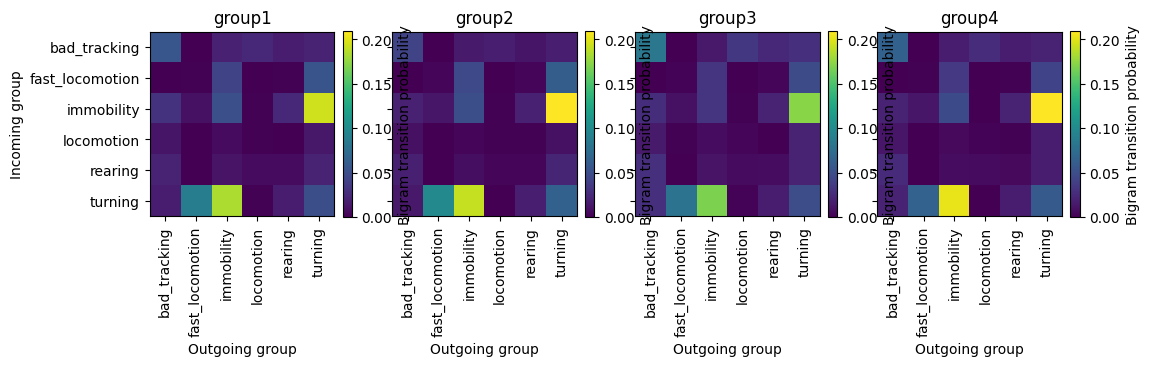

In [13]:
normalize = "bigram"

trans_mats, usages, groups, syll_include = kpms.generate_transition_matrices(
    project_dir, model_name, normalize=normalize, min_frequency=0.005
)

# 1) group post hoc
grouped_trans_mats, grouped_usages, group_names, grp_ids = group_transitions_posthoc(
    project_dir,
    model_name,
    trans_mats,
    usages,
    syll_include,
    group_col="label",       # uses syll_info.csv label column
    fillna="UNLABELED",      # put unlabeled syllables in one bucket
    normalize=normalize,
)

# 2) plot grouped heatmaps
visualize_grouped_transition_bigram(
    project_dir,
    model_name,
    groups,
    grouped_trans_mats,
    group_names,
    normalize=normalize,
    figsize=(12, 6),
    cmap = 'viridis',
    formats = 'svg', 
    save_dir = '/Users/annateruel/Desktop/'
    
)

Saved figure to /Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/2026_01_09-12_30_09/figures/transition_graphs_diff.png


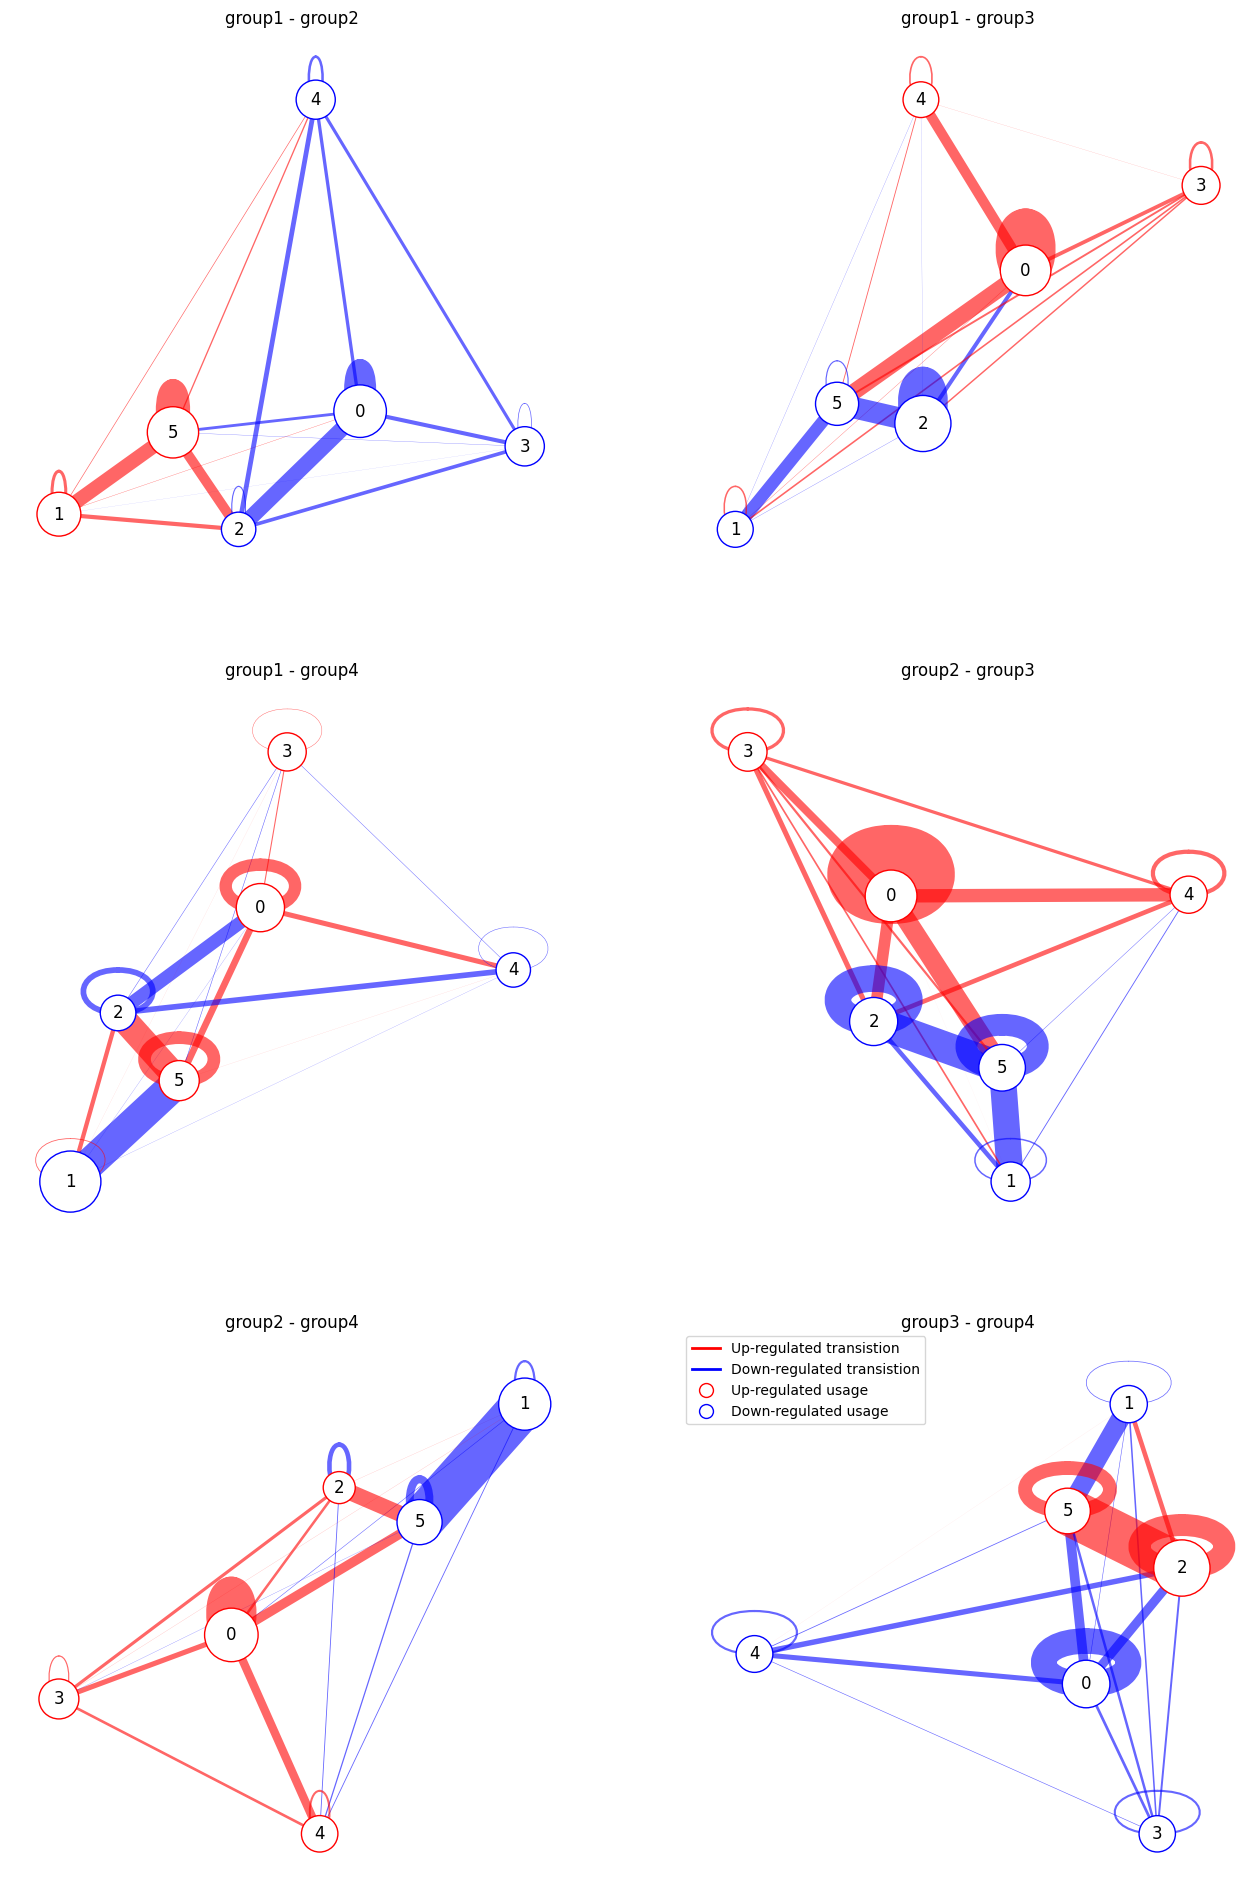

In [21]:
kpms.plot_transition_graph_difference(
    project_dir, model_name, groups, grouped_trans_mats, grouped_usages, syll_include, layout="spring", show_syllable_names=False, 
)
plt.savefig("/Users/annateruel/Desktop/transition_graph_difference.svg",
            bbox_inches="tight")

Saved figure to /Volumes/ANNA_HD/ANALYSIS/EXPERIMENTS/2026/wanhui-3cham/results_v2_13_01_26/2026_01_09-12_30_09/figures/transition_graphs.png


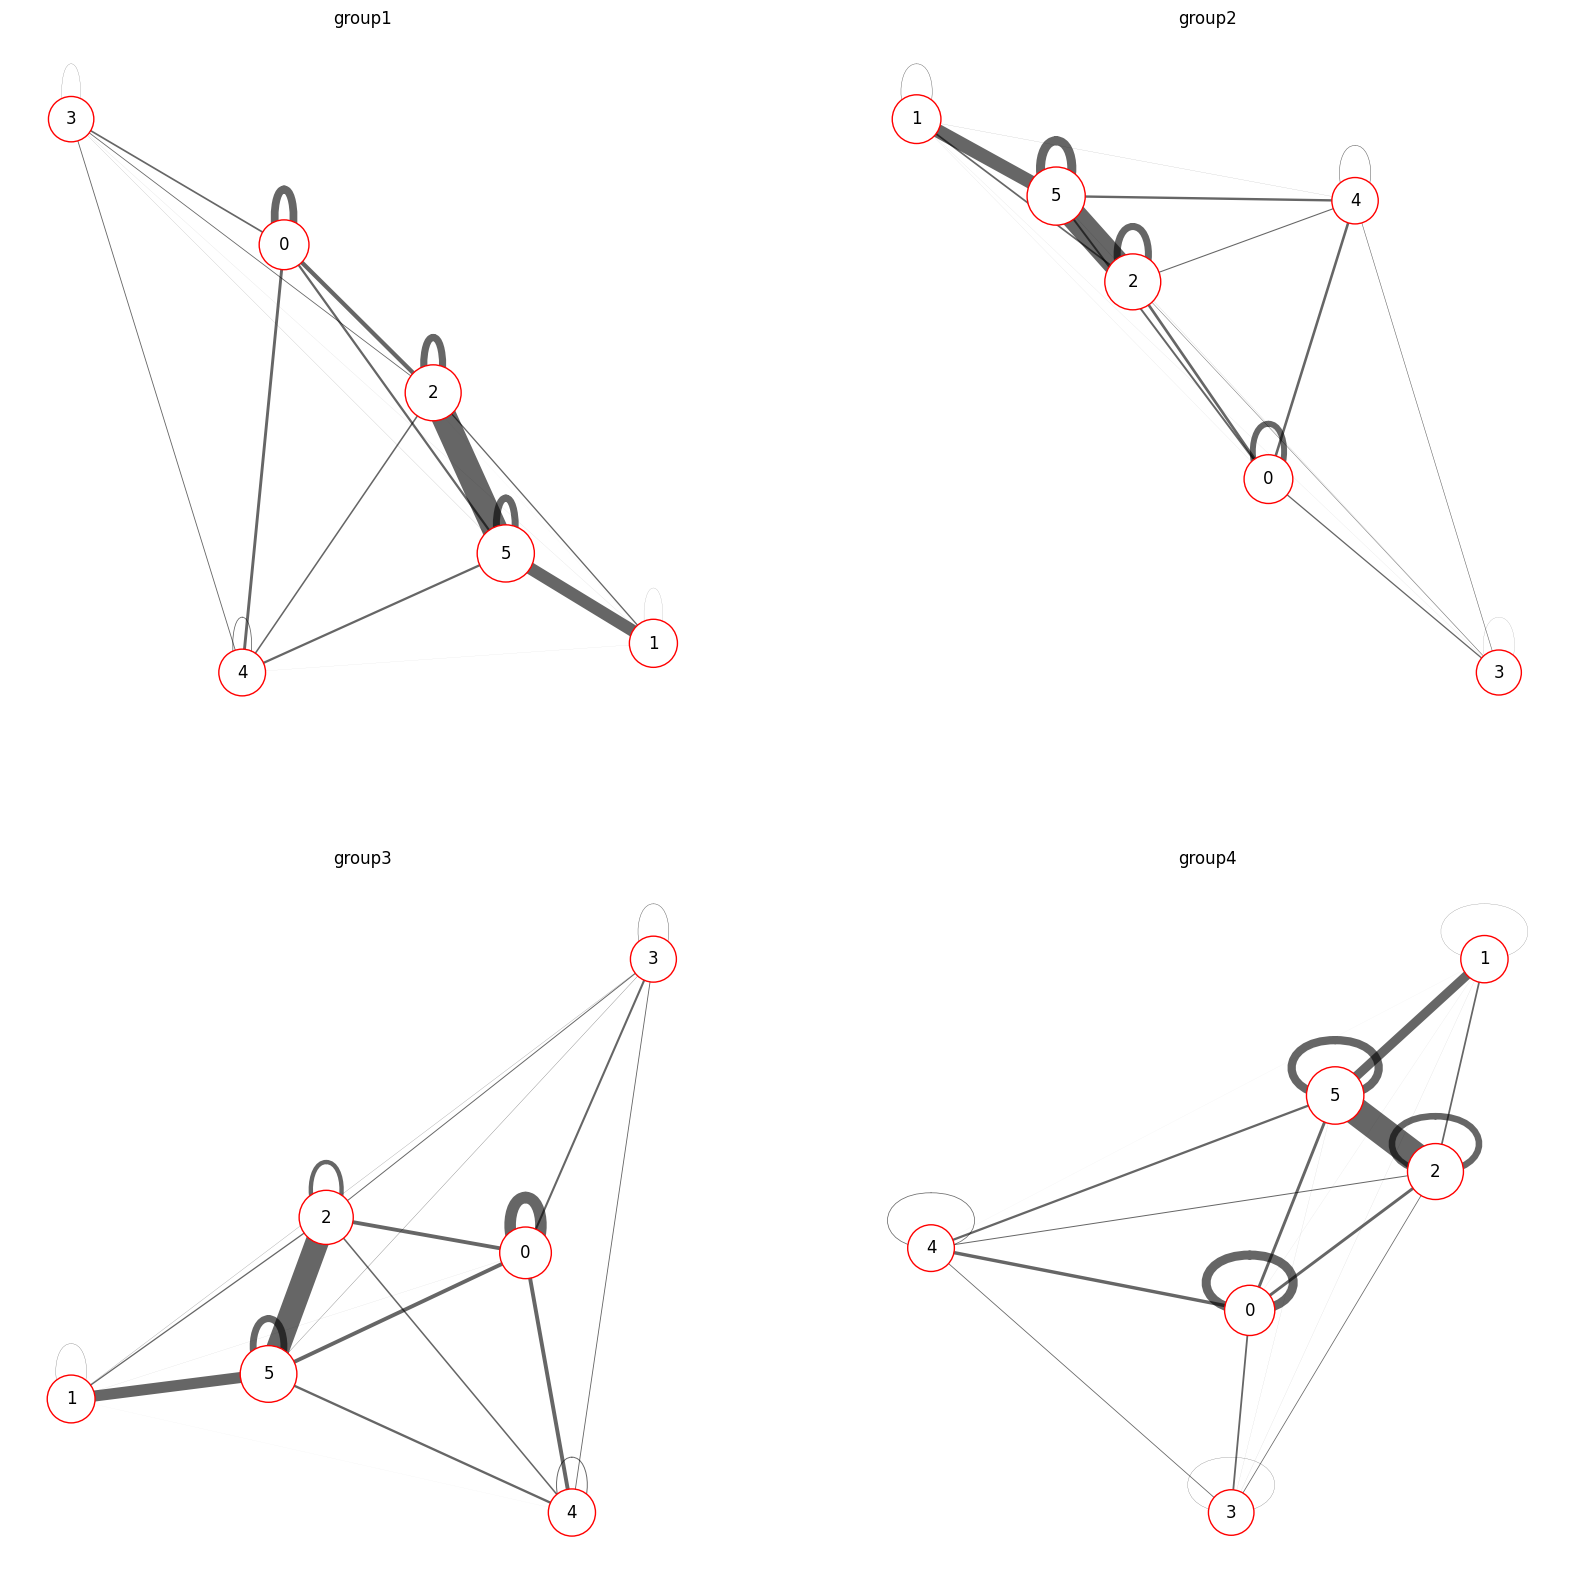

In [20]:
kpms.plot_transition_graph_group(
    project_dir,
    model_name,
    groups,
    grouped_trans_mats,
    grouped_usages,
    syll_include,
    layout="spring",  # transition graph layout ("circular" or "spring")
    show_syllable_names=False,  # label syllables by index (False) or index and name (True)
)

plt.savefig("/Users/annateruel/Desktop/transition_graph.svg",
            bbox_inches="tight")

In [22]:
for i, n in enumerate(group_names):
    print(i, n)

0 bad_tracking
1 fast_locomotion
2 immobility
3 locomotion
4 rearing
5 turning


Transition probabilities per chamber (e.g. NA vs A) or Within-ROI transitions. 

Compute transitions only using frames inside a given ROI (e.g. chamber)

In [23]:
import numpy as np

def collapsed_sequence(labels):
    """Return sequence with consecutive repeats removed."""
    labels = np.asarray(labels)
    if len(labels) == 0:
        return labels
    keep = np.r_[True, labels[1:] != labels[:-1]]
    return labels[keep]
def transition_matrix_per_roi(
    moseq_df,
    roi,
    max_syllable=100,
    min_frequency=0.005,
    normalize="bigram",          # "bigram" | "rows" | "columns"
    smoothing=0.0,
):
    """
    Returns one matrix per (name) for a specific ROI, plus a combined matrix.
    """
    # filter to ROI
    df = moseq_df[moseq_df["roi_index"] == roi].copy()

    # optional: drop rare syllables globally (use your same min_frequency filtering)
    # easiest: reuse syll_include you already computed elsewhere and pass it in
    # Here: just keep as-is unless you pass syll_include externally

    mats = []
    for name, sub in df.groupby("name"):
        seq = collapsed_sequence(sub["syllable"].to_numpy())
        # bigram counts
        T = np.zeros((max_syllable, max_syllable), float)
        for a, b in zip(seq[:-1], seq[1:]):
            if a < max_syllable and b < max_syllable:
                T[a, b] += 1
        T = T + smoothing
        T = normalize_transition_matrix(T, normalize)  # use kpms helper if you want
        mats.append(T)

    # combined across animals in ROI
    T_combined = np.sum(mats, axis=0)
    T_combined = normalize_transition_matrix(T_combined, normalize)

    return mats, T_combined
def transition_matrix_conditioned_on_roi(
    moseq_df,
    roi,
    max_syllable=100,
    normalize="bigram",
    smoothing=0.0,
    mode="start",   # "start" = roi at t, "end" = roi at t+1
):
    mats = []
    for name, sub in moseq_df.groupby("name"):
        syll = sub["syllable"].to_numpy()
        roi_idx = sub["roi_index"].to_numpy()

        # find transitions on full framewise sequence
        change = np.r_[False, syll[1:] != syll[:-1]]
        trans_locs = np.where(change)[0]           # indices where a new syllable starts
        trans_syll = syll[trans_locs]              # syllable at those points
        trans_roi  = roi_idx[trans_locs]           # roi at those points

        # build bigram on the collapsed sequence
        seq = trans_syll
        seq_roi = trans_roi

        T = np.zeros((max_syllable, max_syllable), float)
        for i in range(len(seq) - 1):
            a, b = seq[i], seq[i+1]
            if mode == "start":
                ok = (seq_roi[i] == roi)
            else:  # mode == "end"
                ok = (seq_roi[i+1] == roi)

            if ok and a < max_syllable and b < max_syllable:
                T[a, b] += 1

        T = T + smoothing
        T = normalize_transition_matrix(T, normalize)
        mats.append(T)

    T_combined = normalize_transition_matrix(np.sum(mats, axis=0), normalize)
    return mats, T_combined


In [24]:
roi_list = sorted(moseq_df["roi_index"].unique())
group_list = sorted(moseq_df["group"].unique())

T_group_roi = {}  # (group, roi) -> matrix

for g in group_list:
    df_g = moseq_df[moseq_df["group"] == g]
    for roi in roi_list:
        _, T = transition_matrix_conditioned_on_roi(df_g, roi=roi, mode="start")
        T_group_roi[(g, roi)] = T

NameError: name 'moseq_df' is not defined